# Analyze Model Predictions

This notebook helps understand and diagnose splice-site model predictions by:
- Loading a pretrained or finetuned model
- Evaluating on validation/test sequences  
- Computing AUPRC and usage correlation metrics
- Visualizing predictions vs ground truth
- Analyzing CDS mask effects on performance

Use this to diagnose performance issues, understand what the model learned, and compare pretrained vs finetuned models.

## 1. Configuration

Set paths and evaluation parameters.

In [1]:
SPLICE_CLASS_NAMES = ["Donor+", "Acceptor+", "Donor-", "Acceptor-"]
BACKGROUND_CLASS = 4
CLASS_LABELS = {0: 'donor +', 1: 'acceptor +', 2: 'donor -', 3: 'acceptor -', 4: 'no splice site'}
CLASS_COLORS  = {0: '#ff7f00', 1: '#33a02c', 2: '#fdbf6f', 3: '#b2df8a', 4: '#1f78b4'}

TISSUE_COLORS = {
    'Brain': '#3399cc',
    'Midbrain': '#34b3e6',
    'Cerebellum': '#34ccff',
    'Heart': '#cc0100',
    'Kidney': '#cc9900',
    'Liver': '#339900',
    'Ovary': '#cc329a',
    'Testis': '#ff6600'
}

SPECIES_ORDER = ['human', 'mouse', 'rat', 'rabbit', 'opossum', 'chicken'] # 'macaque'
TISSUE_ORDER = ["Brain", "Midbrain", "Cerebellum", "Heart", "Kidney", "Liver", "Ovary", "Testis"]

In [2]:
# ── Model Selection ────────────────────────────────────────────────────────
# Choose ONE: pretrained or finetuned model

# Option 1: Pretrained model (sanity check)
MODEL_TYPE = "pretrained"
CHECKPOINT_DIR = "/home/elek/projects/alphagenome_ft_pytorch/checkpoints"
CHECKPOINT_PATH = f"{CHECKPOINT_DIR}/pretrained.pth"
MODEL_CONFIG = f"{CHECKPOINT_DIR}/config.json"

# Option 2: Finetuned model (uncomment to use)
MODEL_TYPE = "finetuned"
CHECKPOINT_DIR = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_human_mouse_rat_rabbit_opossum"
CHECKPOINT_PATH = f"{CHECKPOINT_DIR}/best_model.pth"
MODEL_CONFIG = f"{CHECKPOINT_DIR}/config.json"

# ── Data Configuration ─────────────────────────────────────────────────────
DATA_CONFIG = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/data_config.json"
EVAL_SPECIES = "human"  # Options: human, mouse, rat, rabbit, opossum

# ── Evaluation Settings ────────────────────────────────────────────────────
DEVICE = "cuda"
BATCH_SIZE = 8
MAX_WINDOWS = 500  # Number of windows to sample (None for all)
SEQUENCE_LENGTH = 131_072
RANDOM_SEED = 1950

print(f"Model: {MODEL_TYPE}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Evaluating: {EVAL_SPECIES}")
print(f"Max windows: {MAX_WINDOWS}")

Model: finetuned
Checkpoint: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_human_mouse_rat_rabbit_opossum/best_model.pth
Evaluating: human
Max windows: 500


## 2. Load Data Configuration

Parse data config to get genome paths, annotations, and BED files.

In [3]:
import json
from pathlib import Path

# Load data config
with open(DATA_CONFIG) as f:
    data_config = json.load(f)

species_spec = data_config[EVAL_SPECIES]

# Expand ~ paths
def expand_path(p):
    return str(Path(p).expanduser())

GENOME_PATH = expand_path(species_spec["genome"])
ANNOTATION_PATH = expand_path(species_spec["annotation_parquet"])
ANNOTATION_PATH = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/splice_sites_intersect.parquet"
USAGE_PATH = expand_path(species_spec["usage_parquet"])
TEST_BED = expand_path(species_spec["test_bed"])
#TEST_BED = "/home/elek/sds/sd17d003/Anamaria/borzoi_folds/results_orthologs_132kb/human/fold0/test_all.bed"

# Species to organism_index mapping
SPECIES_TO_ORG_IDX = {
    "human": 0,
    "mouse": 1,
    "rat": 2,
    "rabbit": 3,
    "opossum": 4,
}
ORGANISM_IDX = SPECIES_TO_ORG_IDX[EVAL_SPECIES]

print(f"\nData paths for {EVAL_SPECIES}:")
print(f"  Genome: {GENOME_PATH}")
print(f"  Annotation: {ANNOTATION_PATH}")
print(f"  Usage: {USAGE_PATH}")
print(f"  Test BED: {TEST_BED}")
print(f"  Organism index: {ORGANISM_IDX}")


Data paths for human:
  Genome: /home/elek/sds/sd17d003/Anamaria/genomes/ensembl115/fasta/Homo_sapiens.fa
  Annotation: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/splice_sites_intersect.parquet
  Usage: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/usage.parquet
  Test BED: /home/elek/sds/sd17d003/Anamaria/borzoi_folds/results_orthologs_132kb/human/fold0/test.bed
  Organism index: 0


## 3. Load Model

Load the pretrained or finetuned model with all heads.

In [4]:
import sys
import torch
import torch.nn as nn
import os

sys.path.insert(0, '/home/elek/projects/alphagenome_ft_pytorch/src')

from alphagenome_pytorch.model import AlphaGenome
from alphagenome_pytorch.config import DtypePolicy
from alphagenome_pytorch.extensions.finetuning.heads import (
    create_splice_classification_finetuning_head,
    create_splice_usage_finetuning_head,
)
from alphagenome_pytorch.extensions.finetuning.transfer import (
    TransferConfig,
    prepare_for_transfer,
    remove_all_heads,
    load_trunk,
)

# Load model config
with open(MODEL_CONFIG) as f:
    cfg = json.load(f)

print(f"\nModel configuration:")
print(f"  Mode: {cfg.get('mode', 'inference')}")
print(f"  Organisms: {cfg.get('num_organisms', 2)}")

# Determine num_organisms (match evaluate_splice.py logic)
if "species_specs" in cfg:
    num_organisms = max(s["organism_index"] for s in cfg["species_specs"]) + 1
else:
    num_organisms = cfg.get("num_organisms", 2)

# Set dtype policy (match evaluate_splice.py logic)
dtype_str = cfg.get("dtype", "bfloat16")
dtype_policy = (
    DtypePolicy.full_float32() if dtype_str == "float32"
    else DtypePolicy.mixed_precision()
)

print(f"  Dtype: {dtype_str}")
print(f"  Num organisms: {num_organisms}")

# Initialize model (same as evaluate_splice.py)
model = AlphaGenome(num_organisms=num_organisms, dtype_policy=dtype_policy)

# Load checkpoint
ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
print(f"\nCheckpoint epoch: {ckpt.get('epoch', 'N/A')}")

# Load pretrained trunk weights if specified in config (match evaluate_splice.py)
if "pretrained_weights" in cfg:
    _pretrained = Path(os.path.expandvars(os.path.expanduser(cfg["pretrained_weights"])))
    if not _pretrained.exists():
        # Fallback to local checkpoints directory
        _fallback = Path("/home/elek/projects/alphagenome_ft_pytorch/checkpoints") / _pretrained.name
        if _fallback.exists():
            print(f"Pretrained weights not found at {_pretrained}; using fallback {_fallback}")
            _pretrained = _fallback
    
    if _pretrained.exists():
        print(f"Loading pretrained trunk from: {_pretrained}")
        model = load_trunk(model, str(_pretrained), exclude_heads=True)
    else:
        print(f"Warning: Pretrained weights not found at {_pretrained}")

# Remove heads (will re-add finetuned ones)
model = remove_all_heads(model)

# Apply LoRA if configured (match evaluate_splice.py)
if cfg.get("mode") == "lora" and cfg.get("lora_rank", 0) > 0:
    lora_targets = [t.strip() for t in cfg["lora_targets"].split(",")]
    print(f"\nApplying LoRA:")
    print(f"  Rank: {cfg['lora_rank']}")
    print(f"  Alpha: {cfg['lora_alpha']}")
    print(f"  Targets: {lora_targets}")
    
    lora_cfg = TransferConfig(
        mode="lora",
        lora_targets=lora_targets,
        lora_rank=cfg["lora_rank"],
        lora_alpha=cfg["lora_alpha"],
    )
    model = prepare_for_transfer(model, lora_cfg)

# Attach classification head
cls_head = create_splice_classification_finetuning_head(num_organisms=num_organisms)
model.splice_sites_classification_head = cls_head

# Attach usage heads (per-organism) - match evaluate_splice.py
species_n_conditions = {int(k): v for k, v in cfg.get("species_n_conditions", {}).items()}
usage_heads_modules = {}
for org_idx, n_cond in species_n_conditions.items():
    if n_cond > 0:
        head = create_splice_usage_finetuning_head(
            n_conditions=n_cond,
            num_organisms=num_organisms,
        )
        usage_heads_modules[str(org_idx)] = head

if usage_heads_modules:
    model.splice_sites_usage_head = nn.ModuleDict(usage_heads_modules)
    print(f"\nUsage heads: {list(usage_heads_modules.keys())}")
else:
    model.splice_sites_usage_head = None
    print("\nNo usage heads configured")

# Load finetuned weights (strip _orig_mod. prefix from torch.compile)
raw_sd = ckpt["model_state_dict"]
sd = {(k[len("_orig_mod."):] if k.startswith("_orig_mod.") else k): v for k, v in raw_sd.items()}
model.load_state_dict(sd, strict=False)

# Load usage head weights from separate storage
usage_heads_state_dicts = ckpt.get("usage_heads_state_dicts", {})
if model.splice_sites_usage_head is not None and usage_heads_state_dicts:
    for org_key, raw_usd in usage_heads_state_dicts.items():
        if org_key in model.splice_sites_usage_head:
            usd = {(k[len("_orig_mod."):] if k.startswith("_orig_mod.") else k): v for k, v in raw_usd.items()}
            model.splice_sites_usage_head[org_key].load_state_dict(usd)

model.to(DEVICE).eval()
print(f"\n✓ Model loaded and ready on {DEVICE}")


Model configuration:
  Mode: lora
  Organisms: 2
  Dtype: bfloat16
  Num organisms: 5


/home/elek/projects/alphagenome_ft_pytorch/src/alphagenome_pytorch/model.py:285: UserWarning: AlphaGenome with num_organisms=5 > 2 is not officially supported. Splice heads will use extended defaults (last organism = mouse config). For finetuning, these heads are typically removed and replaced.
  warnings.warn(



Checkpoint epoch: 3
Loading pretrained trunk from: /home/elek/projects/alphagenome_ft_pytorch/checkpoints/model_fold_0.safetensors
Skipped 4 parameter(s) with shape mismatches:
  embedder_128bp.organism_embed.weight: checkpoint torch.Size([2, 3072]) vs model torch.Size([5, 3072])
  embedder_1bp.organism_embed.weight: checkpoint torch.Size([2, 1536]) vs model torch.Size([5, 1536])
  embedder_pair.organism_embed.weight: checkpoint torch.Size([2, 128]) vs model torch.Size([5, 128])
  organism_embed.weight: checkpoint torch.Size([2, 1536]) vs model torch.Size([5, 1536])

Applying LoRA:
  Rank: 8
  Alpha: 16
  Targets: ['q_proj', 'v_proj']

Usage heads: ['0', '1', '2', '3', '4']

✓ Model loaded and ready on cuda


## 4. Load Dataset

Create dataset with gene body (CDS) masks for evaluation.

In [5]:
import numpy as np
from torch.utils.data import DataLoader

from alphagenome_pytorch.extensions.finetuning.splice_datasets import (
    SpliceSiteDataset,
    SpliceSiteAnnotation,
    SpliceSiteUsageIndex,
    collate_splice,
)
from alphagenome_pytorch.extensions.finetuning.datasets import CachedGenome

print("Loading annotations...")
annotation = SpliceSiteAnnotation(ANNOTATION_PATH)

print("Loading usage index...")
usage_index = SpliceSiteUsageIndex(
    USAGE_PATH,
    min_coverage=10,
    usage_coord_base=1,
)


Loading annotations...
SpliceSiteAnnotation: loaded 423,630 sites across 44 chromosomes from splice_sites_intersect.parquet
Loading usage index...
SpliceSiteUsageIndex: loaded 1,636,667 sites, 88 conditions from usage.parquet


In [6]:
print("Loading genome...")
genome = CachedGenome(GENOME_PATH)

Loading genome...
CachedGenome: Loading genome from /home/elek/sds/sd17d003/Anamaria/genomes/ensembl115/fasta/Homo_sapiens.fa...
CachedGenome: Loaded 194 chromosomes (12399.0 MB)


In [7]:
print("Creating dataset...")
dataset = SpliceSiteDataset(
    genome=genome,
    bed_file=TEST_BED,
    annotation=annotation,
    usage_index=usage_index,
    organism_index=ORGANISM_IDX,
    sequence_length=SEQUENCE_LENGTH,
)

# Sample subset if MAX_WINDOWS specified
if MAX_WINDOWS is not None and MAX_WINDOWS < len(dataset):
    np.random.seed(RANDOM_SEED)
    indices = np.random.choice(len(dataset), size=MAX_WINDOWS, replace=False)
    dataset = torch.utils.data.Subset(dataset, indices)
    print(f"\nSampled {MAX_WINDOWS} windows (seed={RANDOM_SEED})")
else:
    print(f"\nUsing all {len(dataset)} windows")

# Create dataloader
loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_splice,
)

print(f"Dataloader ready: {len(loader)} batches")

Creating dataset...

Sampled 500 windows (seed=1950)
Dataloader ready: 63 batches


/home/elek/projects/alphagenome_ft_pytorch/src/alphagenome_pytorch/extensions/finetuning/splice_datasets.py:384: UserWarning: 9 intervals skipped (out of chromosome bounds).
  warnings.warn(


## 5. Run Inference

Use `collect_predictions()` from evaluate_splice.py for consistent inference.

In [8]:
# Add scripts directory to path for importing evaluate_splice functions
import sys
from pathlib import Path

scripts_dir = Path("/home/elek/projects/alphagenome_ft_pytorch/scripts")
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

from evaluate_splice import collect_predictions

# Extract usage_heads dict from model for collect_predictions()
usage_heads = {}
if model.splice_sites_usage_head is not None:
    usage_heads = {int(k): v for k, v in model.splice_sites_usage_head.items()}
    print(f"Usage heads available: {list(usage_heads.keys())}")
else:
    print("No usage heads available")

print(f"\nRunning inference on {len(loader)} batches...")
print(f"  Organism index: {ORGANISM_IDX}")
print(f"  Sequence length: {SEQUENCE_LENGTH}")

# DIAGNOSTIC: Check first batch for loss_mask
first_batch = next(iter(loader))
if "loss_mask" in first_batch:
    loss_mask_sample = first_batch["loss_mask"].numpy()
    print(f"\nDIAGNOSTIC - Loss mask in first batch:")
    print(f"  Shape: {loss_mask_sample.shape}")
    print(f"  True positions: {loss_mask_sample.sum()} / {loss_mask_sample.size} ({100*loss_mask_sample.sum()/loss_mask_sample.size:.1f}%)")
    if loss_mask_sample.sum() == 0:
        print("  ⚠️  WARNING: Loss mask is all False - no positions will be evaluated!")
        print("  This likely means BED file has invalid mask columns or no CDS regions")
else:
    print("\nDIAGNOSTIC - No loss_mask in batch (will evaluate all positions)")

# Recreate loader (since we consumed first batch)
loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_splice,
)

# Run inference using evaluate_splice.py function
cls_probs, cls_labels, usage_per_cond = collect_predictions(
    model=model,
    usage_heads=usage_heads,
    loader=loader,
    device=torch.device(DEVICE),
    organism_index=ORGANISM_IDX,
    seq_len=SEQUENCE_LENGTH,
)

print(f"\n✓ Inference complete")
print(f"  Positions collected: {len(cls_labels):,}")
print(f"  Usage conditions: {len(usage_per_cond)}")

if len(cls_labels) == 0:
    print("\n⚠️  ERROR: No positions collected!")

Usage heads available: [0, 1, 2, 3, 4]

Running inference on 63 batches...
  Organism index: 0
  Sequence length: 131072

DIAGNOSTIC - Loss mask in first batch:
  Shape: (8, 131072)
  True positions: 353060 / 1048576 (33.7%)


  Inference: 100%|██████████| 63/63 [03:55<00:00,  3.74s/batch]



✓ Inference complete
  Positions collected: 15,140,572
  Usage conditions: 88


## 6. Process Predictions

Note: `collect_predictions()` already applies CDS mask filtering if present in the dataset.
If loss_mask exists, the returned arrays contain only CDS positions.

In [9]:
# collect_predictions() returns already-filtered data
# If loss_mask was present: cls_probs and cls_labels contain only CDS positions
# If loss_mask was absent: cls_probs and cls_labels contain all positions

print(f"\nTotal positions after filtering: {len(cls_labels):,}")

# Check label distribution
splice_sites = (cls_labels < BACKGROUND_CLASS)
n_splice = splice_sites.sum()
n_background = (~splice_sites).sum()

print(f"\nLabel distribution:")
print(f"  Splice sites: {n_splice:,} ({100*n_splice/len(cls_labels):.2f}%)")
print(f"  Background: {n_background:,} ({100*n_background/len(cls_labels):.2f}%)")

# Per-class counts
print(f"\nPer-class breakdown:")
for cls_idx, cls_name in enumerate(SPLICE_CLASS_NAMES):
    n = (cls_labels == cls_idx).sum()
    if n > 0:
        print(f"  {cls_name}: {n:,} ({100*n/len(cls_labels):.2f}%)")
    
# Diagnostic: Check if we have reasonable splice site density
if len(cls_labels) > 0:
    splice_density = n_splice / len(cls_labels)
    print(f"\nSplice site density: {splice_density:.4f}")
    
    if splice_density < 0.0001:
        print("⚠️  WARNING: Very low splice site density (<0.01%) - check annotation file")
    elif splice_density > 0.1:
        print("⚠️  WARNING: Very high splice site density (>10%) - unusual for genomic data")


Total positions after filtering: 15,140,572

Label distribution:
  Splice sites: 4,060 (0.03%)
  Background: 15,136,512 (99.97%)

Per-class breakdown:
  Donor+: 875 (0.01%)
  Acceptor+: 877 (0.01%)
  Donor-: 1,154 (0.01%)
  Acceptor-: 1,154 (0.01%)

Splice site density: 0.0003


## 7. Compute Classification Metrics

Calculate AUPRC. Note: if loss_mask was present in dataset, these are CDS-only metrics.

In [10]:
from sklearn.metrics import average_precision_score

def compute_auprc_metrics(probs, labels, prefix=""):
    """Compute classification AUPRC metrics."""
    if len(labels) == 0:
        print(f"\n{prefix}No labels to evaluate!")
        return None
    
    # Binary: any splice site vs background
    y_binary = (labels != BACKGROUND_CLASS).astype(int)
    s_binary = 1.0 - probs[:, BACKGROUND_CLASS]
    binary_auprc = average_precision_score(y_binary, s_binary)
    pos_rate = y_binary.mean()
    
    # Per-class AUPRC
    per_class_auprc = {}
    per_class_n = {}
    
    for cls_idx, cls_name in enumerate(SPLICE_CLASS_NAMES):
        y_c = (labels == cls_idx).astype(int)
        n_pos = y_c.sum()
        
        if n_pos == 0:
            continue
        
        ap = average_precision_score(y_c, probs[:, cls_idx])
        per_class_auprc[cls_name] = ap
        per_class_n[cls_name] = int(n_pos)
    
    mean_per_class = np.mean(list(per_class_auprc.values())) if per_class_auprc else float('nan')
    
    # Print results
    print(f"\n{prefix}Classification AUPRC:")
    print(f"  Positions evaluated: {len(labels):,}")
    print(f"  Positive rate: {pos_rate:.4f} (splice / all)")
    print(f"  Binary AUPRC: {binary_auprc:.4f}")
    print(f"  Mean per-class AUPRC: {mean_per_class:.4f}")
    
    for cls_name, ap in per_class_auprc.items():
        n = per_class_n[cls_name]
        print(f"    {cls_name}: {ap:.4f} (n={n:,})")
    
    return {
        "binary_auprc": binary_auprc,
        "mean_per_class_auprc": mean_per_class,
        "per_class_auprc": per_class_auprc,
        "per_class_n": per_class_n,
        "positive_rate": pos_rate,
        "n_positions": len(labels),
    }

# Compute metrics on the returned data
# (already CDS-filtered if loss_mask was present)
print("="*70)
print("EVALUATION RESULTS")
print("="*70)
metrics = compute_auprc_metrics(cls_probs, cls_labels)

EVALUATION RESULTS

Classification AUPRC:
  Positions evaluated: 15,140,572
  Positive rate: 0.0003 (splice / all)
  Binary AUPRC: 0.7164
  Mean per-class AUPRC: 0.7232
    Donor+: 0.7229 (n=875)
    Acceptor+: 0.7270 (n=877)
    Donor-: 0.7257 (n=1,154)
    Acceptor-: 0.7172 (n=1,154)


Per-class performance metrics including TP, FP, FN, precision, and recall.

In [11]:
import pandas as pd

if metrics is not None and len(cls_labels) > 0:
    pred_classes = np.argmax(cls_probs, axis=1)
    
    rows = []
    for cls_idx, cls_name in enumerate(SPLICE_CLASS_NAMES):
        binary = (cls_labels == cls_idx).astype(int)
        if binary.sum() == 0:
            continue
        
        auprc = average_precision_score(binary, cls_probs[:, cls_idx])
        tp = int(((pred_classes == cls_idx) & (cls_labels == cls_idx)).sum())
        fp = int(((pred_classes == cls_idx) & (cls_labels != cls_idx)).sum())
        fn = int(((pred_classes != cls_idx) & (cls_labels == cls_idx)).sum())
        misclassified = int(((cls_labels == cls_idx) &
                             (pred_classes != cls_idx) &
                             (pred_classes != BACKGROUND_CLASS)).sum())
        
        rows.append(dict(
            Class=CLASS_LABELS[cls_idx],
            AUPRC=round(auprc, 4),
            TP=tp, 
            FP=fp, 
            FN=fn,
            Misclassified=misclassified,
            Precision=round(tp / (tp + fp) if tp + fp else 0, 4),
            Recall=round(tp / (tp + fn) if tp + fn else 0, 4),
        ))
    
    results_df = pd.DataFrame(rows)
    print("\nPer-Class Confusion Matrix Metrics:")
    display(results_df)
    
    # Overall accuracy
    correct = (pred_classes == cls_labels).sum()
    total = len(cls_labels)
    accuracy = correct / total if total > 0 else 0
    
    # Splice site accuracy (excluding background)
    splice_mask = cls_labels != BACKGROUND_CLASS
    if splice_mask.sum() > 0:
        splice_correct = (pred_classes[splice_mask] == cls_labels[splice_mask]).sum()
        splice_accuracy = splice_correct / splice_mask.sum()
        print(f"\nOverall accuracy: {accuracy:.4f}")
        print(f"Splice site accuracy (excluding background): {splice_accuracy:.4f}")
    else:
        print(f"\nOverall accuracy: {accuracy:.4f}")
else:
    print("\nNo data available for confusion matrix")


Per-Class Confusion Matrix Metrics:


,Class,AUPRC,TP,FP,FN,Misclassified,Precision,Recall
0,donor +,0.7229,604,224,271,0,0.7295,0.6903
1,acceptor +,0.7270,623,338,254,0,0.6483,0.7104
2,donor -,0.7257,854,598,300,0,0.5882,0.7400
3,acceptor -,0.7172,859,751,295,1,0.5335,0.7444



Overall accuracy: 0.9998
Splice site accuracy (excluding background): 0.7241


Plot precision-recall curves and usage scatter plots.

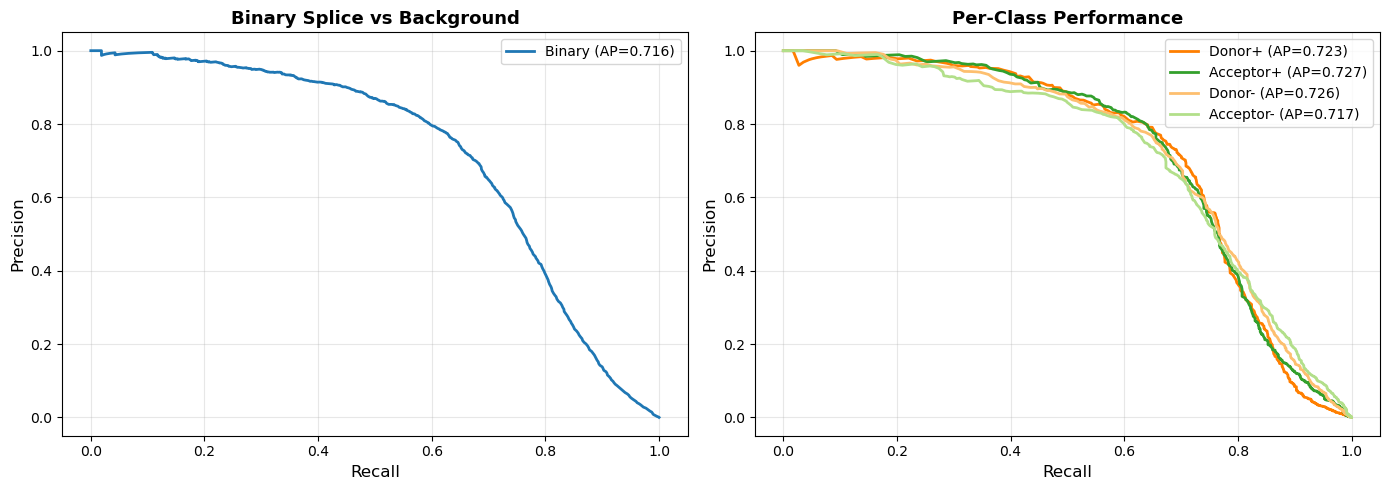

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

if metrics is None:
    print("No metrics to visualize")
else:
    # Plot PR curves for classification
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Binary PR curve
    ax = axes[0]
    y_binary = (cls_labels != BACKGROUND_CLASS).astype(int)
    s_binary = 1.0 - cls_probs[:, BACKGROUND_CLASS]
    precision, recall, _ = precision_recall_curve(y_binary, s_binary)
    ap = metrics['binary_auprc']

    ax.plot(recall, precision, label=f'Binary (AP={ap:.3f})', linewidth=2)

    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title('Binary Splice vs Background', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Per-class PR curves
    ax = axes[1]
    class_colors = ['#ff7f00', '#33a02c', '#fdbf6f', '#b2df8a']

    for cls_idx, (cls_name, color) in enumerate(zip(SPLICE_CLASS_NAMES, class_colors)):
        if cls_name not in metrics['per_class_auprc']:
            continue
        
        y_c = (cls_labels == cls_idx).astype(int)
        s_c = cls_probs[:, cls_idx]
        precision, recall, _ = precision_recall_curve(y_c, s_c)
        ap = metrics['per_class_auprc'][cls_name]
        
        ax.plot(recall, precision, label=f'{cls_name} (AP={ap:.3f})', 
                color=color, linewidth=2)

    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title('Per-Class Performance', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 8. Compute Usage Metrics

Calculate Pearson correlation for usage predictions.

In [13]:
# Import compute_usage_metrics from evaluate_splice.py (already in sys.path)
from evaluate_splice import compute_usage_metrics

if usage_per_cond:
    print("\n" + "="*70)
    print("USAGE PREDICTIONS")
    print("="*70)
    usage_metrics = compute_usage_metrics(usage_per_cond)
    
    print(f"Conditions evaluated: {usage_metrics['usage_n_conditions_evaluated']} / {usage_metrics['usage_n_conditions_total']}")
    print(f"Total observations: {usage_metrics['usage_n_observations']:,}")
    print(f"Mean Pearson r: {usage_metrics['usage_mean_pearson_r']:.4f}")
    print(f"Median Pearson r: {usage_metrics['usage_median_pearson_r']:.4f}")
    print(f"Pooled Pearson r: {usage_metrics['usage_pearson_r']:.4f}")
else:
    print("\nNo usage predictions available")
    usage_metrics = None


USAGE PREDICTIONS
Conditions evaluated: 69 / 88
Total observations: 1,056
Mean Pearson r: -0.1140
Median Pearson r: -0.1223
Pooled Pearson r: -0.0836


## 9. Summary

Final summary of results and interpretation.

In [14]:
print("\n" + "="*70)
print("SUMMARY")
print("="*70)

print(f"\nModel: {MODEL_TYPE}")
print(f"Species: {EVAL_SPECIES}")
print(f"Windows evaluated: {MAX_WINDOWS if MAX_WINDOWS else 'all'}")

if metrics:
    print(f"\n📊 Classification:")
    print(f"  Binary AUPRC: {metrics['binary_auprc']:.4f}")
    print(f"  Mean per-class AUPRC: {metrics['mean_per_class_auprc']:.4f}")
    print(f"  Positions evaluated: {metrics['n_positions']:,}")
    print(f"  Splice site rate: {metrics['positive_rate']:.4f}")

if usage_metrics:
    print(f"\n📈 Usage Predictions:")
    print(f"  Mean Pearson r: {usage_metrics['mean_r']:.4f}")
    print(f"  Median Pearson r: {usage_metrics['median_r']:.4f}")
    print(f"  Pooled Pearson r: {usage_metrics['pooled_r']:.4f}")
    print(f"  Conditions evaluated: {usage_metrics['n_conditions']}")
    print(f"  Total observations: {usage_metrics['n_observations']:,}")

print("\n" + "="*70)


SUMMARY

Model: finetuned
Species: human
Windows evaluated: 500

📊 Classification:
  Binary AUPRC: 0.7164
  Mean per-class AUPRC: 0.7232
  Positions evaluated: 15,140,572
  Splice site rate: 0.0003

📈 Usage Predictions:


KeyError: 'mean_r'